# Machine Learning Based Fraud Dectection

## Overview
This notebook demonstrates end-to-end fraud detection using machine learning models with MLflow experiment tracking. We'll build and compare two models:
- **Logistic Regression** - A simple, interpretable baseline model
- **XGBoost** - A powerful gradient boosting model for improved performance

## Workflow
1. **Data Loading** - Load golden table data for fraud detection
2. **Exploratory Data Analysis (EDA)** - Understand data distributions and patterns
3. **Data Preprocessing** - Prepare features for modeling
4. **Model Training** - Train both Logistic Regression and XGBoost with MLflow
5. **Model Evaluation** - Compare model performance
6. **Model Registration** - Register best model to Unity Catalog

## Key Objectives
- Build production-ready fraud detection models
- Track experiments with MLflow for reproducibility
- Compare multiple modeling approaches
- Document each step for future reference

In [0]:
# Install required libraries for ML modeling
%pip install xgboost scikit-learn mlflow pandas numpy matplotlib seaborn imbalanced-learn --quiet

In [0]:
# Restart Python kernel to load newly installed libraries
dbutils.library.restartPython()

## Step 1: Import Libraries
Importing all necessary libraries for data manipulation, visualization, and machine learning.

In [0]:
# Data manipulation and analysis
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine learning - preprocessing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

# Machine learning - models
from sklearn.linear_model import LogisticRegression
import xgboost as xgb

# Machine learning - evaluation
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
    precision_recall_curve,
    average_precision_score,
    f1_score,
    accuracy_score
)

# MLflow for experiment tracking
import mlflow
import mlflow.sklearn
import mlflow.xgboost
from mlflow.models import infer_signature

# Set display options
pd.set_option('display.max_columns', None)
sns.set_style('whitegrid')

print("✓ All libraries imported successfully")

✓ All libraries imported successfully


## Step 2: Load Golden Table Data
Loading the fraud detection dataset. This dataset contains transaction data with features and a fraud label.

> **Note:**  
> The golden table is obtained via a data pipeline: **Bronze → Silver → Gold**.  
> - **Bronze:** Raw transaction logs  
> - **Silver:** Cleaned and joined features  
> - **Gold:** Feature-enriched, ML-ready data for fraud detection

In [0]:
# Load fraud detection data from golden table
df = spark.table("github.datasets.fraud_gold").toPandas()

print("✓ Data loaded successfully")
print(f"Shape: {df.shape}")
print(f"\nColumns: {list(df.columns)}")
print(f"\nFraud distribution:")
if 'fraud_label' in df.columns:
    print(df['fraud_label'].value_counts())
    print(f"Fraud percentage: {df['fraud_label'].mean() * 100:.2f}%")
else:
    print("Note: 'fraud_label' column not found. Available columns:", list(df.columns))
    print("\nFirst few rows:")
    display(df.head())

✓ Data loaded successfully
Shape: (50000, 25)

Columns: ['transaction_id', 'user_id', 'transaction_amount', 'transaction_type', 'timestamp', 'account_balance', 'device_type', 'location', 'merchant_category', 'ip_address_flag', 'previous_fraudulent_activity', 'daily_transaction_count', 'avg_transaction_amount_7d', 'failed_transaction_count_7d', 'card_type', 'card_age', 'transaction_distance', 'authentication_method', 'risk_score', 'is_weekend', 'fraud_label', 'hour_of_day', 'day_of_week', 'month', 'year']

Fraud distribution:
0    33933
1    16067
Name: fraud_label, dtype: int64
Fraud percentage: 32.13%


### ⚠️ Important: Data Requirements

**This notebook expects the table `github.datasets.fraud_gold` to contain:**

1. **Required Column**: `fraud_label` or similar fraud indicator
   - Binary: 0 = legitimate, 1 = fraud
   - Will be used as target variable

2. **Feature Columns**: Numeric or categorical features
   - Transaction amounts
   - Time-based features (hour, day, etc.)
   - Customer features (account age, transaction history)
   - Risk indicators (IP flags, device info, etc.)

3. **Data Quality**: Clean, complete data ready for modeling
   - No missing values in target
   - Features properly formatted
   - Outliers handled appropriately

## Step 3: Exploratory Data Analysis (EDA)
Understanding our data through statistical summaries, visualizations, and correlation analysis. This is critical for identifying patterns, outliers, and relationships between features and the fraud label.

In [0]:
# Display basic information
print(f"Dataset Shape: {df.shape[0]} rows, {df.shape[1]} columns")
print(f"Memory Usage: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")
print(f"\nMissing Values: {df.isnull().sum().sum()}")

# display(df.head(10))

Dataset Shape: 50000 rows, 25 columns
Memory Usage: 29.00 MB

Missing Values: 0


In [0]:
# Display feature columns and data types
print("Feature columns in dataset:")
for col in df.columns:
    print(f"  - {col}: {df[col].dtype}")

print(f"\nTotal columns: {len(df.columns)}")
print(f"Numeric features: {df.select_dtypes(include=['float64', 'int64']).shape[1]}")
print(f"\nNote: Target variable 'fraud_label' will be separated in preprocessing step")

Feature columns in dataset:
  - transaction_id: object
  - user_id: object
  - transaction_amount: float64
  - transaction_type: object
  - timestamp: datetime64[ns]
  - account_balance: float64
  - device_type: object
  - location: object
  - merchant_category: object
  - ip_address_flag: int32
  - previous_fraudulent_activity: int32
  - daily_transaction_count: int32
  - avg_transaction_amount_7d: float64
  - failed_transaction_count_7d: int32
  - card_type: object
  - card_age: int32
  - transaction_distance: float64
  - authentication_method: object
  - risk_score: float64
  - is_weekend: int32
  - fraud_label: int32
  - hour_of_day: int32
  - day_of_week: int32
  - month: int32
  - year: int32

Total columns: 25
Numeric features: 5

Note: Target variable 'fraud_label' will be separated in preprocessing step


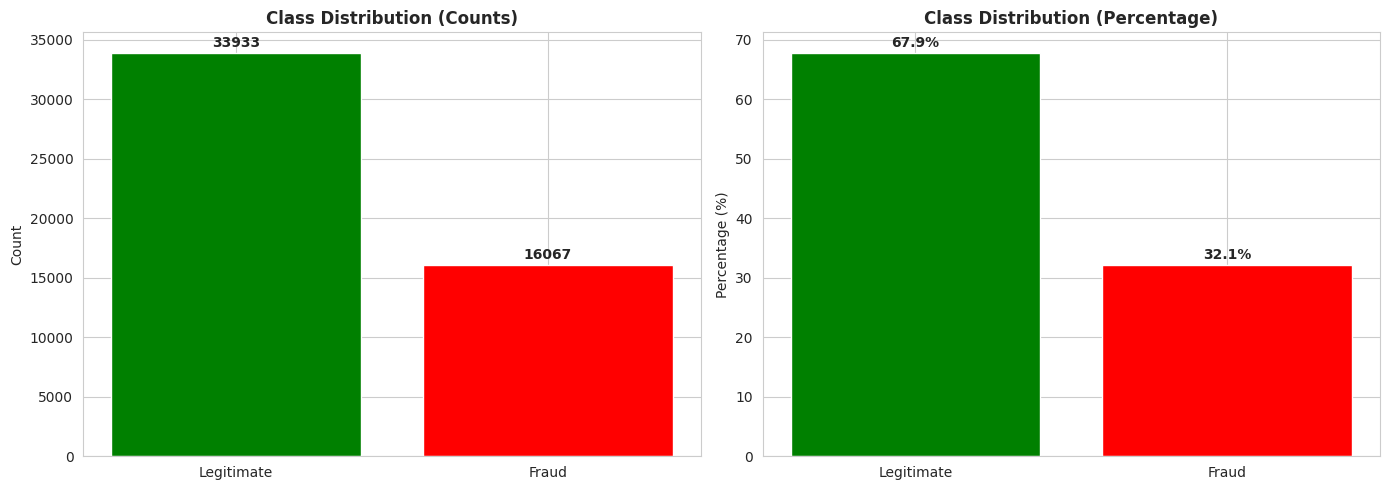

Class balance: 67.87% legitimate, 32.13% fraud
Imbalance ratio: 1:2.11


In [0]:
# Visualize class distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

fraud_counts = df['fraud_label'].value_counts()
axes[0].bar(['Legitimate', 'Fraud'], fraud_counts.values, color=['green', 'red'])
axes[0].set_ylabel('Count')
axes[0].set_title('Class Distribution (Counts)', fontweight='bold')
for i, v in enumerate(fraud_counts.values):
    axes[0].text(i, v + 500, str(v), ha='center', fontweight='bold')

fraud_pct = df['fraud_label'].value_counts(normalize=True) * 100
axes[1].bar(['Legitimate', 'Fraud'], fraud_pct.values, color=['green', 'red'])
axes[1].set_ylabel('Percentage (%)')
axes[1].set_title('Class Distribution (Percentage)', fontweight='bold')
for i, v in enumerate(fraud_pct.values):
    axes[1].text(i, v + 1, f"{v:.1f}%", ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

print(f"Class balance: {fraud_pct[0]:.2f}% legitimate, {fraud_pct[1]:.2f}% fraud")
print(f"Imbalance ratio: 1:{fraud_counts[0]/fraud_counts[1]:.2f}")

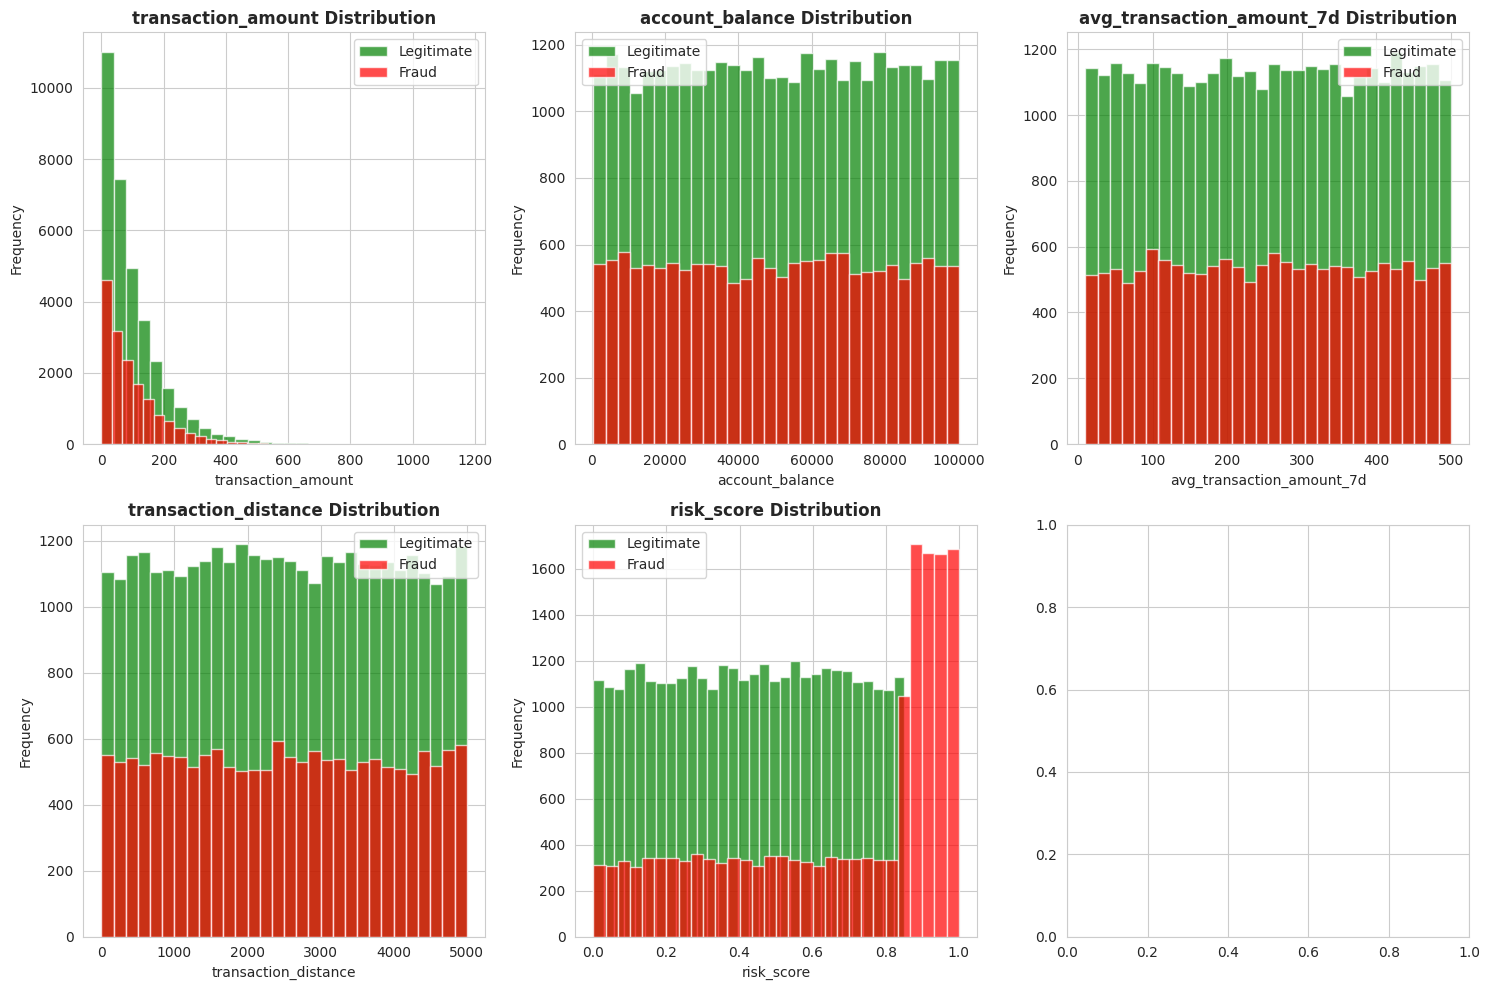

Visualized distributions for 5 features
Total numeric features: 5


In [0]:
# Visualize feature distributions by fraud label
# Select numeric features for visualization (excluding target)
numeric_features = df.select_dtypes(include=['float64', 'int64']).columns.tolist()
if 'fraud_label' in numeric_features:
    numeric_features.remove('fraud_label')

# Plot distributions for first 6 numeric features
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for idx, feature in enumerate(numeric_features[:6]):
    df[df['fraud_label'] == 0][feature].hist(bins=30, alpha=0.7, label='Legitimate', color='green', ax=axes[idx])
    df[df['fraud_label'] == 1][feature].hist(bins=30, alpha=0.7, label='Fraud', color='red', ax=axes[idx])
    axes[idx].set_xlabel(feature)
    axes[idx].set_ylabel('Frequency')
    axes[idx].set_title(f'{feature} Distribution', fontweight='bold')
    axes[idx].legend()

plt.tight_layout()
plt.show()

print(f"Visualized distributions for {len(numeric_features[:6])} features")
print(f"Total numeric features: {len(numeric_features)}")

## Step 4: Data Preprocessing
Preparing data for machine learning models:
1. **Train-Test Split**: Divide data into training (70%), validation (15%), and test (15%) sets
2. **Feature Scaling**: Standardize numeric features (mean=0, std=1)
3. **Feature Engineering**: Select relevant features for modeling

**Key Considerations:**
- Time-based split to preserve temporal order (avoid data leakage)
- Handle class imbalance with model parameters
- Scale features to same magnitude for better convergence

In [0]:
# Separate features and target
# Exclude transaction_id, user_id, and timestamp (not predictive features)
columns_to_exclude = ['transaction_id', 'user_id', 'timestamp', 'fraud_label']
X = df.drop(columns=columns_to_exclude)
y = df['fraud_label']

print(f"Features: {X.shape[1]} columns")
print(f"Samples: {X.shape[0]} rows")
print(f"\nExcluded columns: {[c for c in columns_to_exclude if c != 'fraud_label']}")
print(f"\nFeature columns: {list(X.columns)}")

Features: 21 columns
Samples: 50000 rows

Excluded columns: ['transaction_id', 'user_id', 'timestamp']

Feature columns: ['transaction_amount', 'transaction_type', 'account_balance', 'device_type', 'location', 'merchant_category', 'ip_address_flag', 'previous_fraudulent_activity', 'daily_transaction_count', 'avg_transaction_amount_7d', 'failed_transaction_count_7d', 'card_type', 'card_age', 'transaction_distance', 'authentication_method', 'risk_score', 'is_weekend', 'hour_of_day', 'day_of_week', 'month', 'year']


In [0]:
# Sort by timestamp for temporal split
df_sorted = df.sort_values('timestamp').reset_index(drop=True)

# Recalculate X and y with sorted data
X = df_sorted.drop(columns=columns_to_exclude)
y = df_sorted['fraud_label']

# Time-based split: 70% train, 15% validation, 15% test
n_samples = len(X)
train_end = int(n_samples * 0.70)
val_end = int(n_samples * 0.85)

X_train = X.iloc[:train_end]
y_train = y.iloc[:train_end]
X_val = X.iloc[train_end:val_end]
y_val = y.iloc[train_end:val_end]
X_test = X.iloc[val_end:]
y_test = y.iloc[val_end:]

print("Time-based split (sorted by timestamp):")
print(f"Training: {X_train.shape[0]} samples ({y_train.mean()*100:.2f}% fraud)")
print(f"Validation: {X_val.shape[0]} samples ({y_val.mean()*100:.2f}% fraud)")
print(f"Test: {X_test.shape[0]} samples ({y_test.mean()*100:.2f}% fraud)")
print(f"\nNote: This split preserves temporal order - training on past, validating/testing on future.")

Time-based split (sorted by timestamp):
Training: 35000 samples (32.20% fraud)
Validation: 7500 samples (31.44% fraud)
Test: 7500 samples (32.53% fraud)

Note: This split preserves temporal order - training on past, validating/testing on future.


In [0]:
# Identify numeric and categorical features
numeric_features = X.select_dtypes(include=['int32', 'int64', 'float64']).columns.tolist()
categorical_features = X.select_dtypes(include=['object']).columns.tolist()

print(f"Numeric features ({len(numeric_features)}): {numeric_features}")
print(f"Categorical features ({len(categorical_features)}): {categorical_features}")

# For now, use only numeric features (simpler approach)
# TODO: Add one-hot encoding or target encoding for categorical features in future iterations
X_train_numeric = X_train[numeric_features]
X_val_numeric = X_val[numeric_features]
X_test_numeric = X_test[numeric_features]

# Scale numeric features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_numeric)
X_val_scaled = scaler.transform(X_val_numeric)
X_test_scaled = scaler.transform(X_test_numeric)

print(f"\n✓ Features scaled (mean=0, std=1)")
print(f"✓ Using {len(numeric_features)} numeric features")
print(f"⚠ Note: {len(categorical_features)} categorical features excluded - consider encoding in future iterations")

Numeric features (15): ['transaction_amount', 'account_balance', 'ip_address_flag', 'previous_fraudulent_activity', 'daily_transaction_count', 'avg_transaction_amount_7d', 'failed_transaction_count_7d', 'card_age', 'transaction_distance', 'risk_score', 'is_weekend', 'hour_of_day', 'day_of_week', 'month', 'year']
Categorical features (6): ['transaction_type', 'device_type', 'location', 'merchant_category', 'card_type', 'authentication_method']

✓ Features scaled (mean=0, std=1)
✓ Using 15 numeric features
⚠ Note: 6 categorical features excluded - consider encoding in future iterations


## Step 5: Model Training with MLflow

We'll train two models and track experiments with MLflow:
1. **Logistic Regression** - Simple, interpretable baseline
2. **XGBoost** - Advanced gradient boosting for better performance

MLflow will track:
- Hyperparameters
- Training/validation metrics
- Model artifacts
- Model signatures for deployment

In [0]:
# Set up MLflow experiment
experiment_name = "/Shared/fraud-detection-experiment"
mlflow.set_experiment(experiment_name)

print(f"✓ MLflow experiment: {experiment_name}")

2026/05/17 21:50:28 INFO mlflow.tracking.fluent: Experiment with name '/Shared/fraud-detection-experiment' does not exist. Creating a new experiment.


✓ MLflow experiment: /Shared/fraud-detection-experiment


### Model 1: Logistic Regression
Training a Logistic Regression model as our baseline. This model is:
- **Simple and interpretable** - Easy to understand feature importance
- **Fast to train** - Good for quick iterations
- **Effective for linearly separable data** - Works well when fraud patterns are linear

Using `class_weight='balanced'` to handle class imbalance automatically.

In [0]:
# Train Logistic Regression with MLflow
with mlflow.start_run(run_name="logistic_regression") as run:
    print("Training Logistic Regression...")
    
    # Train model ONLY on training data (no data leakage)
    log_reg = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42, solver='lbfgs')
    log_reg.fit(X_train_scaled, y_train)
    
    # Predictions (validation and test sets are only used for evaluation)
    y_train_pred = log_reg.predict(X_train_scaled)
    y_val_pred = log_reg.predict(X_val_scaled)
    y_train_proba = log_reg.predict_proba(X_train_scaled)[:, 1]
    y_val_proba = log_reg.predict_proba(X_val_scaled)[:, 1]
    
    # Calculate metrics
    train_accuracy = accuracy_score(y_train, y_train_pred)
    val_accuracy = accuracy_score(y_val, y_val_pred)
    train_f1 = f1_score(y_train, y_train_pred)
    val_f1 = f1_score(y_val, y_val_pred)
    train_auc = roc_auc_score(y_train, y_train_proba)
    val_auc = roc_auc_score(y_val, y_val_proba)
    train_ap = average_precision_score(y_train, y_train_proba)
    val_ap = average_precision_score(y_val, y_val_proba)
    
    # Log to MLflow
    mlflow.log_param("model_type", "LogisticRegression")
    mlflow.log_param("class_weight", "balanced")
    mlflow.log_param("max_iter", 1000)
    mlflow.log_metric("train_accuracy", train_accuracy)
    mlflow.log_metric("val_accuracy", val_accuracy)
    mlflow.log_metric("train_f1_score", train_f1)
    mlflow.log_metric("val_f1_score", val_f1)
    mlflow.log_metric("train_auc_roc", train_auc)
    mlflow.log_metric("val_auc_roc", val_auc)
    mlflow.log_metric("train_avg_precision", train_ap)
    mlflow.log_metric("val_avg_precision", val_ap)
    
    # Log model
    signature = infer_signature(X_train_scaled, y_train_pred)
    mlflow.sklearn.log_model(log_reg, "model", signature=signature, input_example=X_train_scaled[:5])
    log_reg_run_id = run.info.run_id
    
    print(f"✓ Training complete (no data leakage: only training data used for fitting)")
    print(f"Val Accuracy: {val_accuracy:.4f} | Val F1: {val_f1:.4f} | Val AUC: {val_auc:.4f}")
    print(f"MLflow Run ID: {log_reg_run_id}")


Validation Set Performance:
              precision    recall  f1-score   support

  Legitimate       0.90      0.80      0.85      5142
       Fraud       0.65      0.80      0.72      2358

    accuracy                           0.80      7500
   macro avg       0.77      0.80      0.78      7500
weighted avg       0.82      0.80      0.81      7500

✓ Confusion matrix saved to MLflow


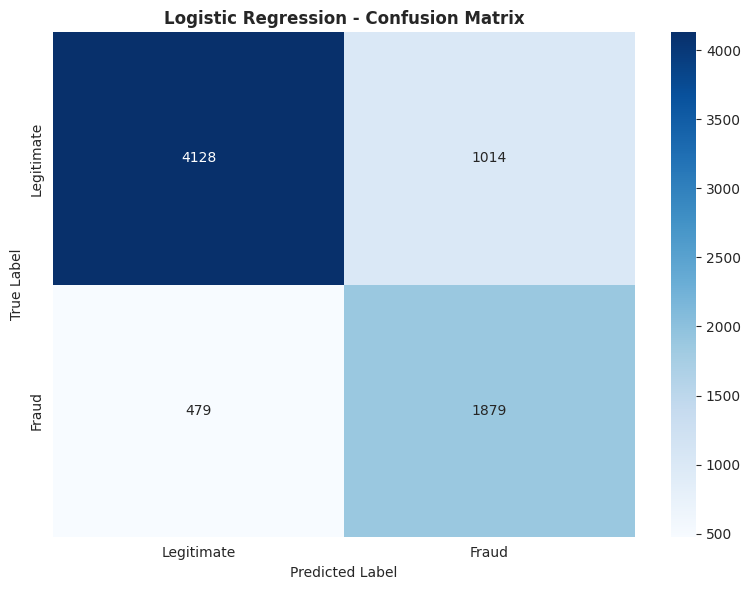

In [0]:
# Confusion Matrix
print("\nValidation Set Performance:")
print(classification_report(y_val, y_val_pred, target_names=['Legitimate', 'Fraud']))

cm = confusion_matrix(y_val, y_val_pred)
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Legitimate', 'Fraud'], yticklabels=['Legitimate', 'Fraud'], ax=ax)
ax.set_ylabel('True Label')
ax.set_xlabel('Predicted Label')
ax.set_title('Logistic Regression - Confusion Matrix', fontweight='bold')
plt.tight_layout()

# Log confusion matrix to MLflow
with mlflow.start_run(run_id=log_reg_run_id):
    mlflow.log_figure(fig, "confusion_matrix.png")
    print("✓ Confusion matrix saved to MLflow")

plt.show()

Top 10 Important Features (by absolute coefficient):


feature,coefficient
failed_transaction_count_7d,1.896113106778452
risk_score,1.5997918644131952
avg_transaction_amount_7d,-0.02398235218603332
transaction_distance,0.018475860377808982
account_balance,-0.015040355263339966
hour_of_day,0.010556059810879677
is_weekend,0.00985977668673142
previous_fraudulent_activity,0.009533697219306638
ip_address_flag,0.0057087770312386375
card_age,0.005278254530491698


✓ Feature importance saved to MLflow


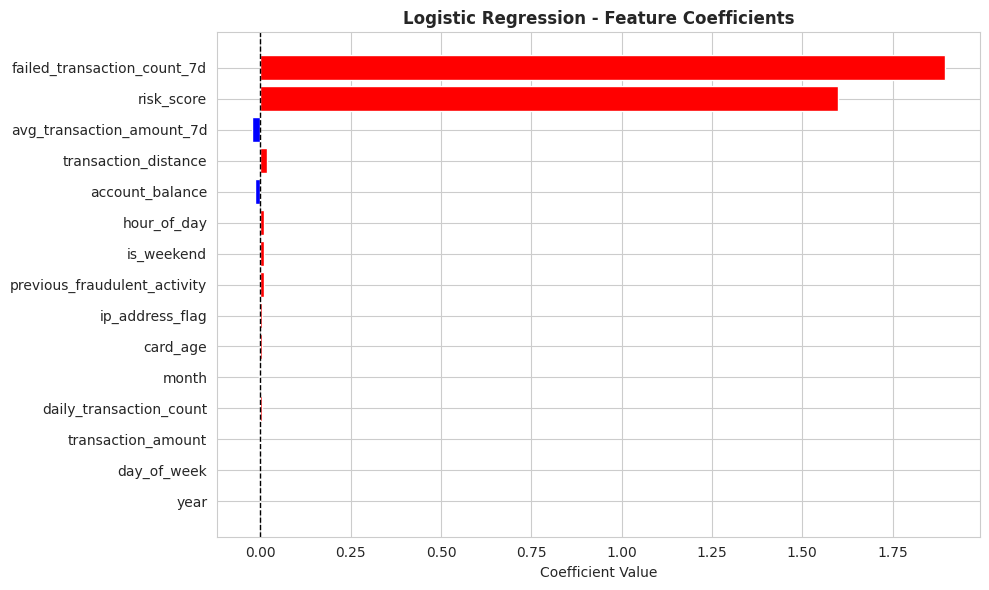

In [0]:
# Feature coefficients (importance) for Logistic Regression
log_reg_coeffs = pd.DataFrame({
    'feature': numeric_features,
    'coefficient': log_reg.coef_[0]
}).sort_values('coefficient', key=abs, ascending=False)

print("Top 10 Important Features (by absolute coefficient):")
display(log_reg_coeffs.head(10))

# Visualize
fig, ax = plt.subplots(figsize=(10, 6))
colors = ['red' if x > 0 else 'blue' for x in log_reg_coeffs['coefficient']]
ax.barh(log_reg_coeffs['feature'], log_reg_coeffs['coefficient'], color=colors)
ax.set_xlabel('Coefficient Value')
ax.set_title('Logistic Regression - Feature Coefficients', fontweight='bold')
ax.axvline(x=0, color='black', linestyle='--', linewidth=1)
ax.invert_yaxis()
plt.tight_layout()

# Log feature importance to MLflow
with mlflow.start_run(run_id=log_reg_run_id):
    mlflow.log_figure(fig, "feature_importance.png")
    print("✓ Feature importance saved to MLflow")

plt.show()

✓ ROC curve saved to MLflow


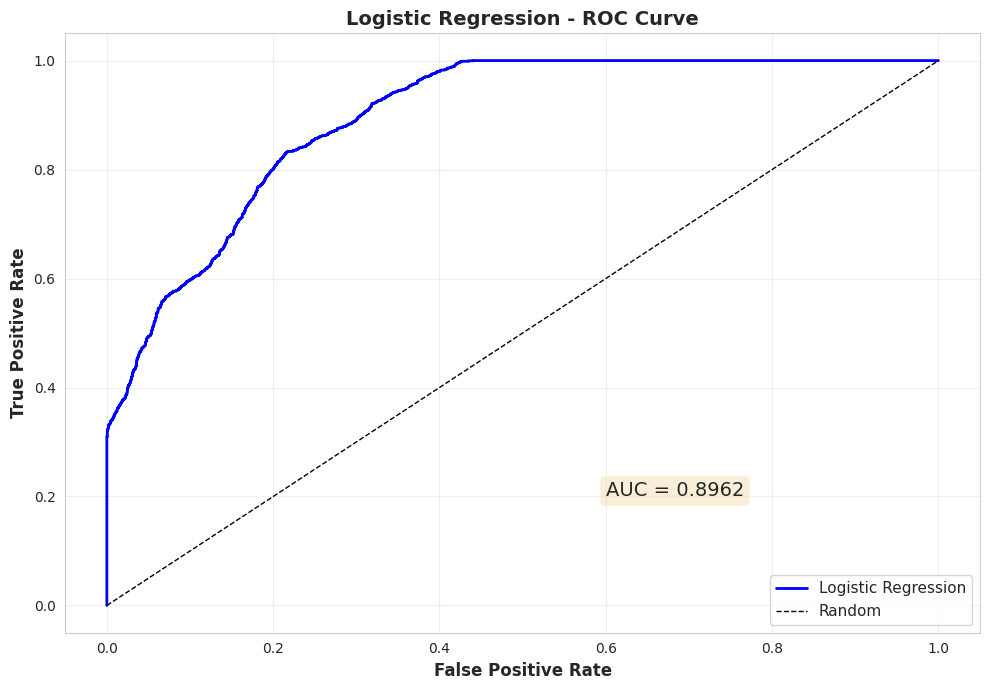

In [0]:
fig, ax = plt.subplots(figsize=(10, 7))
fpr_lr, tpr_lr, _ = roc_curve(y_val, y_val_proba)
ax.plot(fpr_lr, tpr_lr, linewidth=2, color='blue', label='Logistic Regression')
ax.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random')
ax.set_xlabel('False Positive Rate', fontsize=12, fontweight='bold')
ax.set_ylabel('True Positive Rate', fontsize=12, fontweight='bold')
ax.set_title('Logistic Regression - ROC Curve', fontsize=14, fontweight='bold')
ax.legend(loc='lower right', fontsize=11)
ax.grid(alpha=0.3)
ax.text(0.6, 0.2, f'AUC = {val_auc:.4f}', fontsize=14, bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
plt.tight_layout()

# Log ROC curve to MLflow
with mlflow.start_run(run_id=log_reg_run_id):
    mlflow.log_figure(fig, "roc_curve.png")
    print("✓ ROC curve saved to MLflow")

plt.show()

### Model 2: XGBoost
Training an XGBoost classifier for improved performance. XGBoost is:
- **Powerful ensemble method** - Combines multiple decision trees
- **Handles non-linear patterns** - Captures complex fraud patterns
- **Built-in feature importance** - Identifies key fraud indicators
- **Robust to imbalanced data** - With proper scale_pos_weight parameter

In [0]:
# Train XGBoost with MLflow
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

with mlflow.start_run(run_name="xgboost") as run:
    print("Training XGBoost...")
    
    # Train model ONLY on training data (no data leakage)
    xgb_model = xgb.XGBClassifier(
        n_estimators=100, max_depth=6, learning_rate=0.1,
        scale_pos_weight=scale_pos_weight, random_state=42,
        eval_metric='logloss', use_label_encoder=False
    )
    xgb_model.fit(X_train_scaled, y_train, eval_set=[(X_val_scaled, y_val)], verbose=False)
    
    # Predictions (validation and test sets are only used for evaluation)
    y_train_pred_xgb = xgb_model.predict(X_train_scaled)
    y_val_pred_xgb = xgb_model.predict(X_val_scaled)
    y_train_proba_xgb = xgb_model.predict_proba(X_train_scaled)[:, 1]
    y_val_proba_xgb = xgb_model.predict_proba(X_val_scaled)[:, 1]
    
    # Calculate metrics
    train_accuracy_xgb = accuracy_score(y_train, y_train_pred_xgb)
    val_accuracy_xgb = accuracy_score(y_val, y_val_pred_xgb)
    train_f1_xgb = f1_score(y_train, y_train_pred_xgb)
    val_f1_xgb = f1_score(y_val, y_val_pred_xgb)
    train_auc_xgb = roc_auc_score(y_train, y_train_proba_xgb)
    val_auc_xgb = roc_auc_score(y_val, y_val_proba_xgb)
    train_ap_xgb = average_precision_score(y_train, y_train_proba_xgb)
    val_ap_xgb = average_precision_score(y_val, y_val_proba_xgb)
    
    # Log to MLflow
    mlflow.log_param("model_type", "XGBoost")
    mlflow.log_param("n_estimators", 100)
    mlflow.log_param("max_depth", 6)
    mlflow.log_param("learning_rate", 0.1)
    mlflow.log_param("scale_pos_weight", scale_pos_weight)
    mlflow.log_metric("train_accuracy", train_accuracy_xgb)
    mlflow.log_metric("val_accuracy", val_accuracy_xgb)
    mlflow.log_metric("train_f1_score", train_f1_xgb)
    mlflow.log_metric("val_f1_score", val_f1_xgb)
    mlflow.log_metric("train_auc_roc", train_auc_xgb)
    mlflow.log_metric("val_auc_roc", val_auc_xgb)
    mlflow.log_metric("train_avg_precision", train_ap_xgb)
    mlflow.log_metric("val_avg_precision", val_ap_xgb)
    
    # Log model
    signature = infer_signature(X_train_scaled, y_train_pred_xgb)
    mlflow.xgboost.log_model(xgb_model, "model", signature=signature, input_example=X_train_scaled[:5])
    xgb_run_id = run.info.run_id
    
    print(f"✓ Training complete (no data leakage: only training data used for fitting)")
    print(f"Val Accuracy: {val_accuracy_xgb:.4f} | Val F1: {val_f1_xgb:.4f} | Val AUC: {val_auc_xgb:.4f}")
    print(f"MLflow Run ID: {xgb_run_id}")


Validation Set Performance:
              precision    recall  f1-score   support

  Legitimate       1.00      1.00      1.00      5142
       Fraud       1.00      1.00      1.00      2358

    accuracy                           1.00      7500
   macro avg       1.00      1.00      1.00      7500
weighted avg       1.00      1.00      1.00      7500

✓ Confusion matrix saved to MLflow


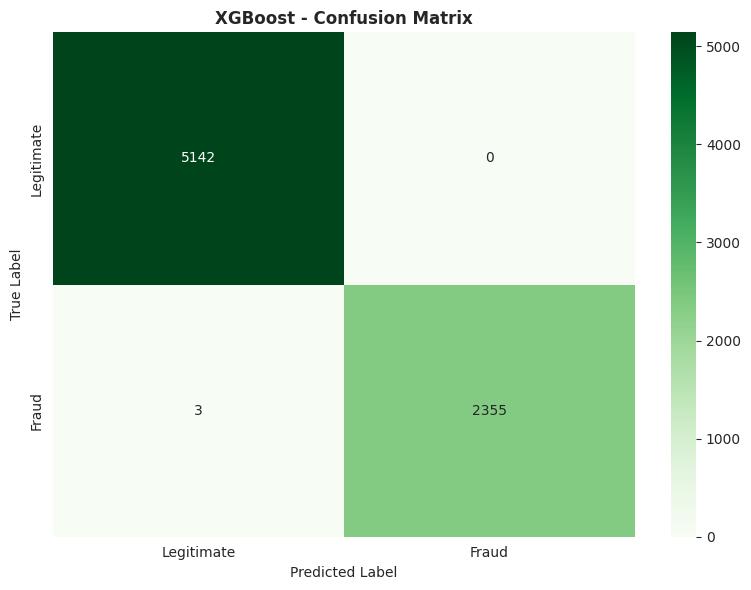

In [0]:
# Confusion Matrix
print("\nValidation Set Performance:")
print(classification_report(y_val, y_val_pred_xgb, target_names=['Legitimate', 'Fraud']))

cm_xgb = confusion_matrix(y_val, y_val_pred_xgb)
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cm_xgb, annot=True, fmt='d', cmap='Greens', xticklabels=['Legitimate', 'Fraud'], yticklabels=['Legitimate', 'Fraud'], ax=ax)
ax.set_ylabel('True Label')
ax.set_xlabel('Predicted Label')
ax.set_title('XGBoost - Confusion Matrix', fontweight='bold')
plt.tight_layout()

# Log confusion matrix to MLflow
with mlflow.start_run(run_id=xgb_run_id):
    mlflow.log_figure(fig, "confusion_matrix.png")
    print("✓ Confusion matrix saved to MLflow")

plt.show()

Top 10 Important Features:


feature,importance
failed_transaction_count_7d,0.60365105
risk_score,0.39056325
daily_transaction_count,8.2882494E-4
avg_transaction_amount_7d,7.781635E-4
day_of_week,6.628896E-4
transaction_distance,6.6159933E-4
month,5.648415E-4
hour_of_day,5.2164576E-4
account_balance,4.975392E-4
card_age,4.5353928E-4


✓ Feature importance saved to MLflow


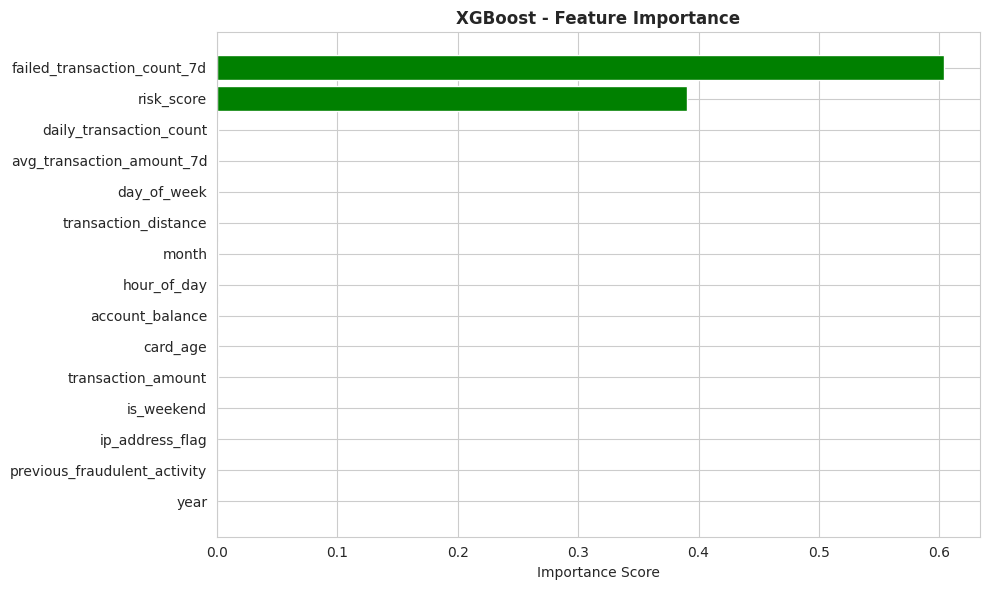

In [0]:
# Feature importance
feature_importance = pd.DataFrame({
    'feature': numeric_features,
    'importance': xgb_model.feature_importances_
}).sort_values('importance', ascending=False)

print("Top 10 Important Features:")
display(feature_importance.head(10))

# Visualize
fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(feature_importance['feature'], feature_importance['importance'], color='green')
ax.set_xlabel('Importance Score')
ax.set_title('XGBoost - Feature Importance', fontweight='bold')
ax.invert_yaxis()
plt.tight_layout()

# Log feature importance to MLflow
with mlflow.start_run(run_id=xgb_run_id):
    mlflow.log_figure(fig, "feature_importance.png")
    print("✓ Feature importance saved to MLflow")

plt.show()

✓ ROC curve saved to MLflow


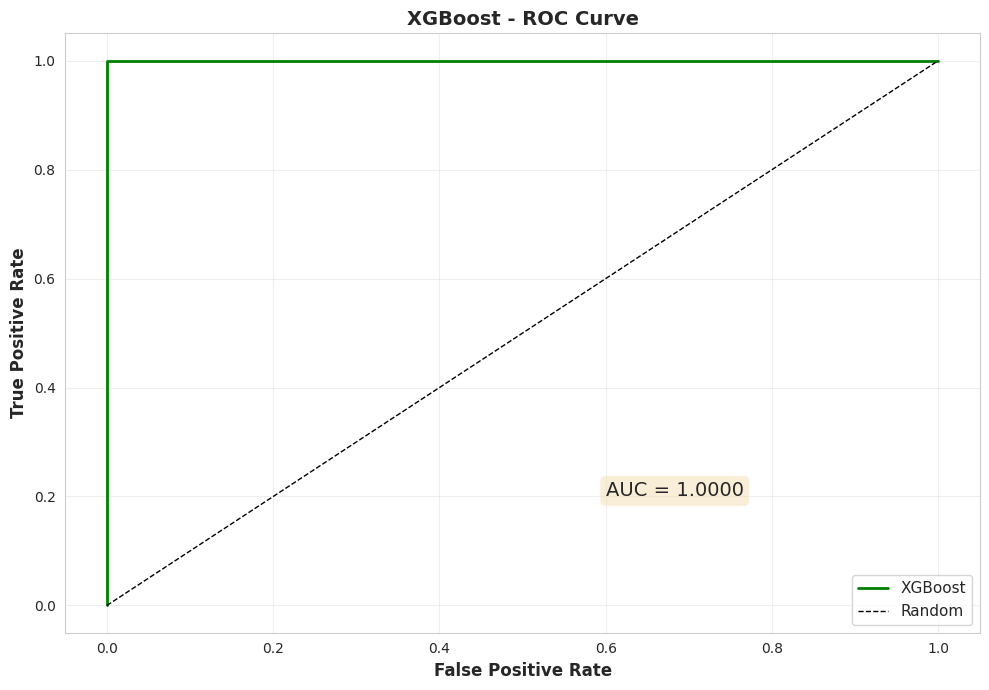

In [0]:
fig, ax = plt.subplots(figsize=(10, 7))
fpr_xgb, tpr_xgb, _ = roc_curve(y_val, y_val_proba_xgb)
ax.plot(fpr_xgb, tpr_xgb, linewidth=2, color='green', label='XGBoost')
ax.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random')
ax.set_xlabel('False Positive Rate', fontsize=12, fontweight='bold')
ax.set_ylabel('True Positive Rate', fontsize=12, fontweight='bold')
ax.set_title('XGBoost - ROC Curve', fontsize=14, fontweight='bold')
ax.legend(loc='lower right', fontsize=11)
ax.grid(alpha=0.3)
ax.text(0.6, 0.2, f'AUC = {val_auc_xgb:.4f}', fontsize=14, bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
plt.tight_layout()

# Log ROC curve to MLflow
with mlflow.start_run(run_id=xgb_run_id):
    mlflow.log_figure(fig, "roc_curve.png")
    print("✓ ROC curve saved to MLflow")

plt.show()

Top 10 Features by Model:


feature,log_reg,xgboost
failed_transaction_count_7d,1.896113106778452,0.60365105
risk_score,1.5997918644131952,0.39056325
daily_transaction_count,0.004181686196568916,8.2882494E-4
avg_transaction_amount_7d,0.02398235218603332,7.781635E-4
day_of_week,0.001553902164713322,6.628896E-4
transaction_distance,0.018475860377808982,6.6159933E-4
month,0.004319439726105264,5.648415E-4
hour_of_day,0.010556059810879677,5.2164576E-4
account_balance,0.015040355263339966,4.975392E-4
card_age,0.005278254530491698,4.5353928E-4


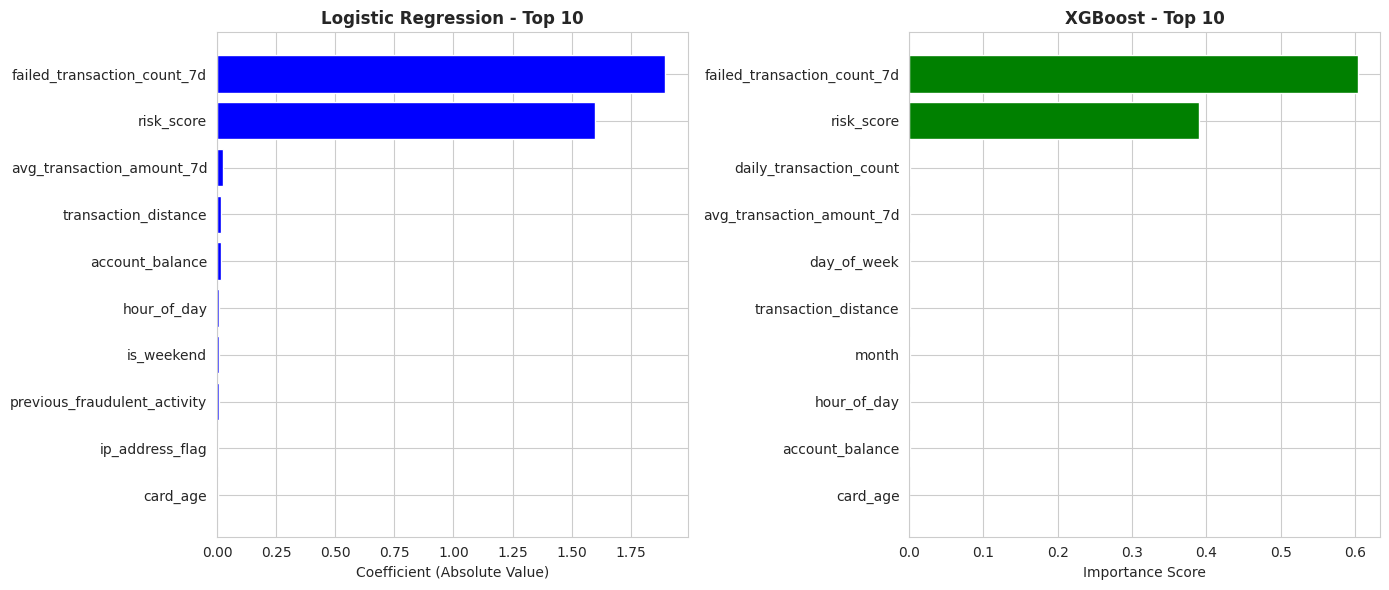

In [0]:
# Compare feature importance between models
log_reg_imp = pd.DataFrame({'feature': numeric_features, 'log_reg': np.abs(log_reg.coef_[0])})
xgb_imp = pd.DataFrame({'feature': numeric_features, 'xgboost': xgb_model.feature_importances_})
comparison = log_reg_imp.merge(xgb_imp, on='feature').sort_values('xgboost', ascending=False)

print("Top 10 Features by Model:")
display(comparison.head(10))

# Visualize side by side
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

top10_lr = comparison.nlargest(10, 'log_reg')
axes[0].barh(top10_lr['feature'], top10_lr['log_reg'], color='blue')
axes[0].set_xlabel('Coefficient (Absolute Value)')
axes[0].set_title('Logistic Regression - Top 10', fontweight='bold')
axes[0].invert_yaxis()

top10_xgb = comparison.nlargest(10, 'xgboost')
axes[1].barh(top10_xgb['feature'], top10_xgb['xgboost'], color='green')
axes[1].set_xlabel('Importance Score')
axes[1].set_title('XGBoost - Top 10', fontweight='bold')
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

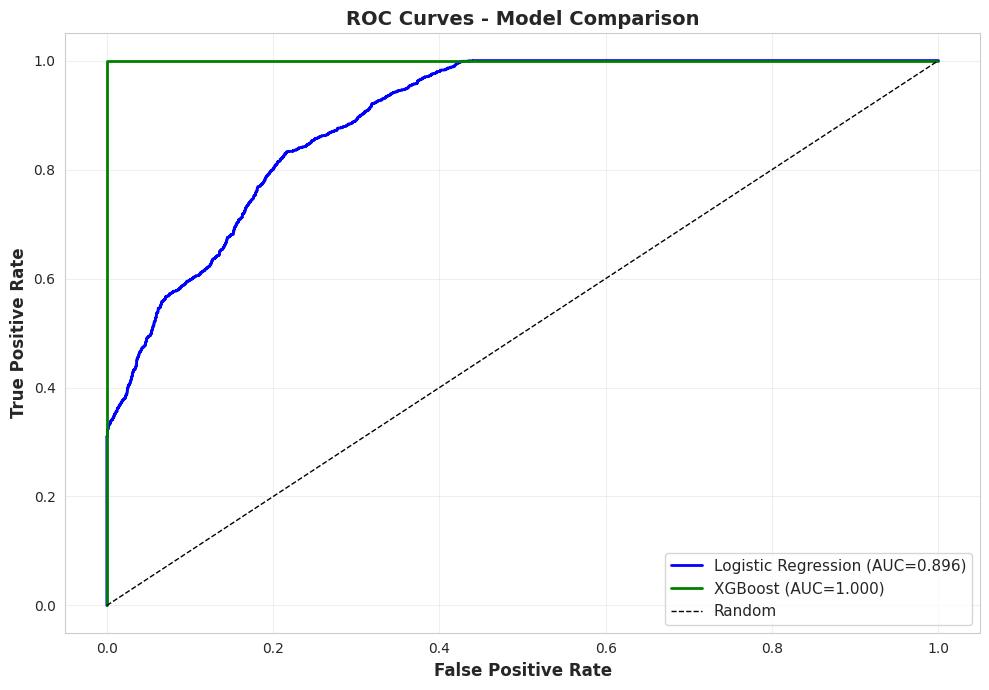

In [0]:
# ROC Curves Comparison
fig, ax = plt.subplots(figsize=(10, 7))

fpr_lr, tpr_lr, _ = roc_curve(y_val, y_val_proba)
fpr_xgb, tpr_xgb, _ = roc_curve(y_val, y_val_proba_xgb)

ax.plot(fpr_lr, tpr_lr, label=f'Logistic Regression (AUC={val_auc:.3f})', linewidth=2, color='blue')
ax.plot(fpr_xgb, tpr_xgb, label=f'XGBoost (AUC={val_auc_xgb:.3f})', linewidth=2, color='green')
ax.plot([0, 1], [0, 1], 'k--', label='Random', linewidth=1)

ax.set_xlabel('False Positive Rate', fontsize=12, fontweight='bold')
ax.set_ylabel('True Positive Rate', fontsize=12, fontweight='bold')
ax.set_title('ROC Curves - Model Comparison', fontsize=14, fontweight='bold')
ax.legend(loc='lower right', fontsize=11)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## Step 6: Model Comparison & Selection

Comparing both models across multiple metrics to select the best performer:
- **Accuracy**: Overall correctness
- **F1 Score**: Balance between precision and recall (critical for imbalanced data)
- **AUC-ROC**: Overall discrimination ability
- **Average Precision**: Area under precision-recall curve (better for imbalanced data)

For fraud detection, **F1 Score and Average Precision** are typically most important.

In [0]:
# Compare model performance
comparison_df = pd.DataFrame({
    'Metric': ['Accuracy', 'F1 Score', 'AUC-ROC', 'Avg Precision'],
    'Log Reg (Train)': [train_accuracy, train_f1, train_auc, train_ap],
    'Log Reg (Val)': [val_accuracy, val_f1, val_auc, val_ap],
    'XGBoost (Train)': [train_accuracy_xgb, train_f1_xgb, train_auc_xgb, train_ap_xgb],
    'XGBoost (Val)': [val_accuracy_xgb, val_f1_xgb, val_auc_xgb, val_ap_xgb]
})

print("Model Performance Comparison:")
display(comparison_df.round(4))

print(f"\n✅ Logistic Regression: Val F1={val_f1:.4f}, Val AUC={val_auc:.4f}")
print(f"✅ XGBoost: Val F1={val_f1_xgb:.4f}, Val AUC={val_auc_xgb:.4f}")

Model Performance Comparison:


Metric,Log Reg (Train),Log Reg (Val),XGBoost (Train),XGBoost (Val)
Accuracy,0.802,0.8009,1.0,0.9996
F1 Score,0.7242,0.7157,1.0,0.9994
AUC-ROC,0.899,0.8962,1.0,1.0
Avg Precision,0.8205,0.8089,1.0,1.0



✅ Logistic Regression: Val F1=0.7157, Val AUC=0.8962
✅ XGBoost: Val F1=0.9994, Val AUC=1.0000


In [0]:
# Calculate precision and recall
from sklearn.metrics import precision_score, recall_score

train_precision_lr = precision_score(y_train, y_train_pred)
val_precision_lr = precision_score(y_val, y_val_pred)
train_recall_lr = recall_score(y_train, y_train_pred)
val_recall_lr = recall_score(y_val, y_val_pred)

train_precision_xgb = precision_score(y_train, y_train_pred_xgb)
val_precision_xgb = precision_score(y_val, y_val_pred_xgb)
train_recall_xgb = recall_score(y_train, y_train_pred_xgb)
val_recall_xgb = recall_score(y_val, y_val_pred_xgb)

detailed_df = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1 Score', 'AUC-ROC', 'Avg Precision'],
    'Log Reg (Train)': [train_accuracy, train_precision_lr, train_recall_lr, train_f1, train_auc, train_ap],
    'Log Reg (Val)': [val_accuracy, val_precision_lr, val_recall_lr, val_f1, val_auc, val_ap],
    'XGBoost (Train)': [train_accuracy_xgb, train_precision_xgb, train_recall_xgb, train_f1_xgb, train_auc_xgb, train_ap_xgb],
    'XGBoost (Val)': [val_accuracy_xgb, val_precision_xgb, val_recall_xgb, val_f1_xgb, val_auc_xgb, val_ap_xgb]
})

print("Detailed Model Metrics:")
display(detailed_df.round(4))

Detailed Model Metrics:


Metric,Log Reg (Train),Log Reg (Val),XGBoost (Train),XGBoost (Val)
Accuracy,0.802,0.8009,1.0,0.9996
Precision,0.6566,0.6495,1.0,1.0
Recall,0.8073,0.7969,1.0,0.9987
F1 Score,0.7242,0.7157,1.0,0.9994
AUC-ROC,0.899,0.8962,1.0,1.0
Avg Precision,0.8205,0.8089,1.0,1.0


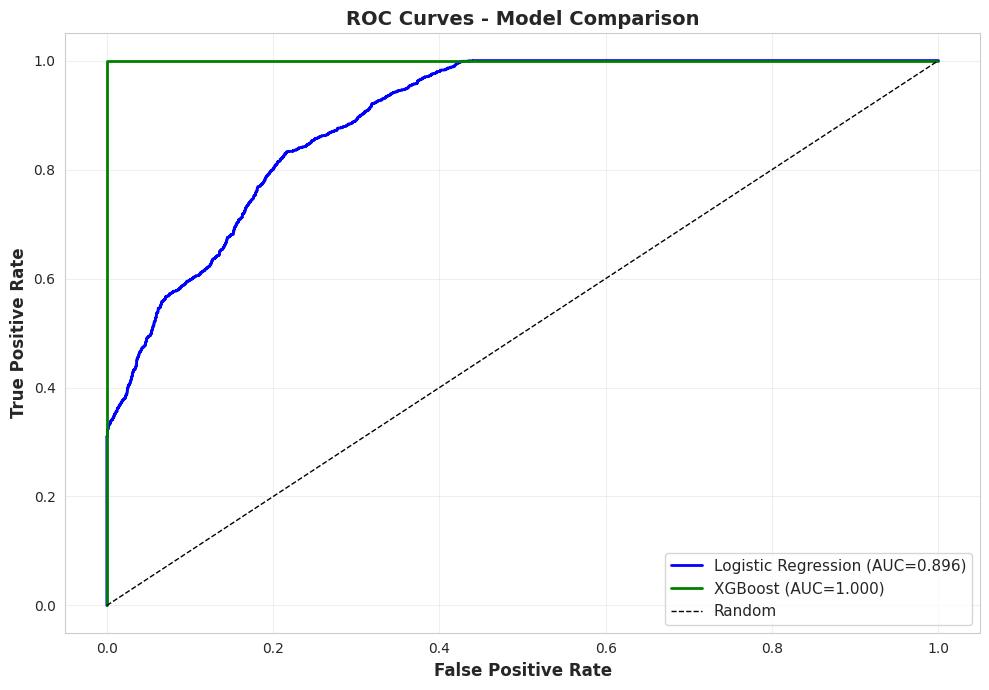

In [0]:
# ROC Curves
fig, ax = plt.subplots(figsize=(10, 7))

fpr_lr, tpr_lr, _ = roc_curve(y_val, y_val_proba)
fpr_xgb, tpr_xgb, _ = roc_curve(y_val, y_val_proba_xgb)

ax.plot(fpr_lr, tpr_lr, label=f'Logistic Regression (AUC={val_auc:.3f})', linewidth=2, color='blue')
ax.plot(fpr_xgb, tpr_xgb, label=f'XGBoost (AUC={val_auc_xgb:.3f})', linewidth=2, color='green')
ax.plot([0, 1], [0, 1], 'k--', label='Random', linewidth=1)

ax.set_xlabel('False Positive Rate', fontsize=12, fontweight='bold')
ax.set_ylabel('True Positive Rate', fontsize=12, fontweight='bold')
ax.set_title('ROC Curves - Model Comparison', fontsize=14, fontweight='bold')
ax.legend(loc='lower right', fontsize=11)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

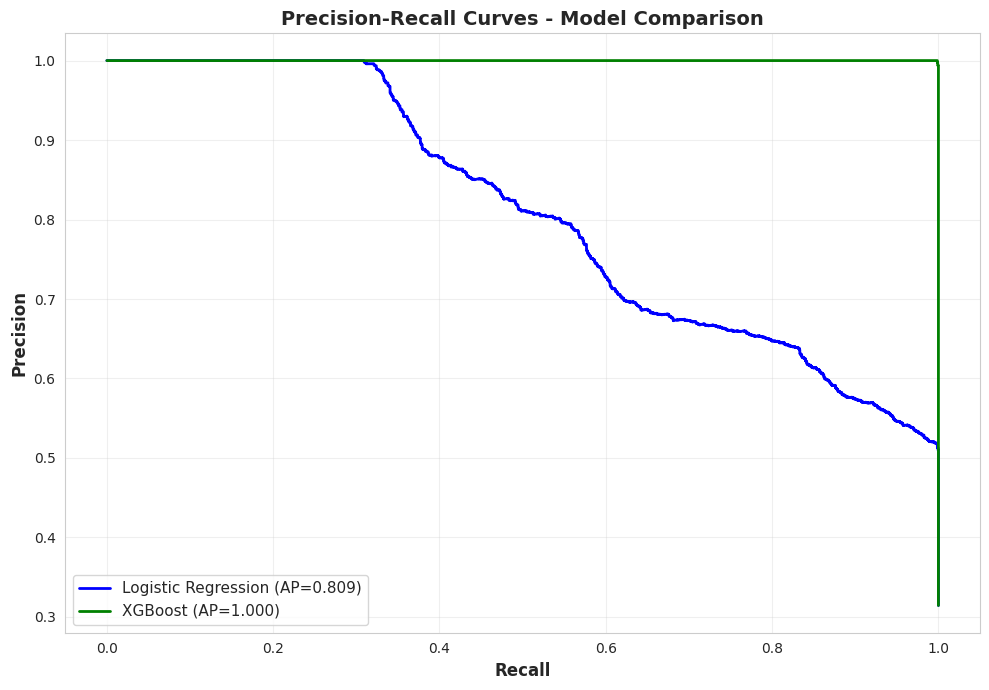

In [0]:
# Precision-Recall Curves
fig, ax = plt.subplots(figsize=(10, 7))

precision_lr, recall_lr, _ = precision_recall_curve(y_val, y_val_proba)
precision_xgb, recall_xgb, _ = precision_recall_curve(y_val, y_val_proba_xgb)

ax.plot(recall_lr, precision_lr, label=f'Logistic Regression (AP={val_ap:.3f})', linewidth=2, color='blue')
ax.plot(recall_xgb, precision_xgb, label=f'XGBoost (AP={val_ap_xgb:.3f})', linewidth=2, color='green')

ax.set_xlabel('Recall', fontsize=12, fontweight='bold')
ax.set_ylabel('Precision', fontsize=12, fontweight='bold')
ax.set_title('Precision-Recall Curves - Model Comparison', fontsize=14, fontweight='bold')
ax.legend(loc='lower left', fontsize=11)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

✅ Best Model: XGBoost
Run ID: 45bbbdfa594943c7ba2fe8de93d7415f

Test Set Results:
Accuracy: 0.9993 | F1: 0.9990 | AUC: 1.0000

Classification Report:
              precision    recall  f1-score   support

  Legitimate       1.00      1.00      1.00      5060
       Fraud       1.00      1.00      1.00      2440

    accuracy                           1.00      7500
   macro avg       1.00      1.00      1.00      7500
weighted avg       1.00      1.00      1.00      7500


✓ Test metrics and confusion matrix saved to MLflow


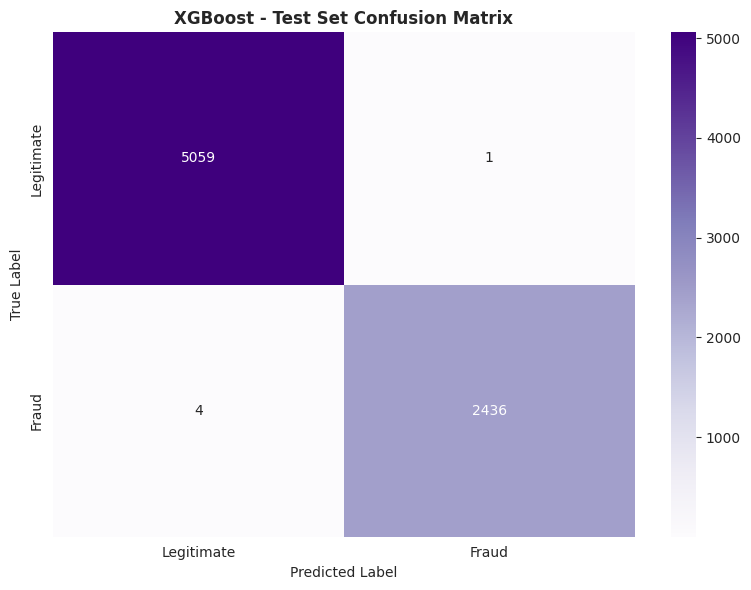

In [0]:
# Select best model and evaluate on test set
if val_f1_xgb > val_f1:
    best_model = xgb_model
    best_model_name = "XGBoost"
    winner_run_id = xgb_run_id
else:
    best_model = log_reg
    best_model_name = "Logistic Regression"
    winner_run_id = log_reg_run_id

print(f"✅ Best Model: {best_model_name}")
print(f"Run ID: {winner_run_id}")

# Evaluate on test set
y_test_pred = best_model.predict(X_test_scaled)
y_test_proba = best_model.predict_proba(X_test_scaled)[:, 1]

test_accuracy = accuracy_score(y_test, y_test_pred)
test_f1 = f1_score(y_test, y_test_pred)
test_auc = roc_auc_score(y_test, y_test_proba)

print(f"\nTest Set Results:")
print(f"Accuracy: {test_accuracy:.4f} | F1: {test_f1:.4f} | AUC: {test_auc:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_test_pred, target_names=['Legitimate', 'Fraud']))

# Confusion matrix
fig, ax = plt.subplots(figsize=(8, 6))
cm_test = confusion_matrix(y_test, y_test_pred)
sns.heatmap(cm_test, annot=True, fmt='d', cmap='Purples', xticklabels=['Legitimate', 'Fraud'], yticklabels=['Legitimate', 'Fraud'], ax=ax)
ax.set_ylabel('True Label')
ax.set_xlabel('Predicted Label')
ax.set_title(f'{best_model_name} - Test Set Confusion Matrix', fontweight='bold')
plt.tight_layout()

# Log test metrics and confusion matrix to MLflow
with mlflow.start_run(run_id=winner_run_id):
    mlflow.log_metric("test_accuracy", test_accuracy)
    mlflow.log_metric("test_f1_score", test_f1)
    mlflow.log_metric("test_auc_roc", test_auc)
    mlflow.log_figure(fig, "test_confusion_matrix.png")
    print("\n✓ Test metrics and confusion matrix saved to MLflow")

plt.show()

### Best Model Selection for Production

**Decision Criteria:**

For fraud detection in production, we prioritize:
1. **F1 Score**: Balance between catching fraud (recall) and minimizing false alarms (precision)
2. **Recall**: Must catch as much fraud as possible
3. **AUC-ROC**: Overall discrimination ability
4. **Generalization**: Minimal gap between training and validation performance

**Model Selection Process:**
- Compare validation metrics (not training metrics to avoid overfitting)
- Prioritize F1 Score for balanced performance
- Consider business requirements (cost of false positives vs false negatives)
- Evaluate model interpretability needs

In [0]:
# Model selection comparison
selection_df = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1 Score', 'AUC-ROC'],
    'Logistic Regression': [val_accuracy, val_precision_lr, val_recall_lr, val_f1, val_auc],
    'XGBoost': [val_accuracy_xgb, val_precision_xgb, val_recall_xgb, val_f1_xgb, val_auc_xgb],
    'Winner': [
        'XGBoost' if val_accuracy_xgb > val_accuracy else 'Log Reg',
        'XGBoost' if val_precision_xgb > val_precision_lr else 'Log Reg',
        'XGBoost' if val_recall_xgb > val_recall_lr else 'Log Reg',
        'XGBoost' if val_f1_xgb > val_f1 else 'Log Reg',
        'XGBoost' if val_auc_xgb > val_auc else 'Log Reg'
    ]
})

print("Model Selection (Validation Set):")
display(selection_df.round(4))

# Final decision
winner = "XGBoost" if val_f1_xgb > val_f1 else "Logistic Regression"
winner_f1 = val_f1_xgb if val_f1_xgb > val_f1 else val_f1
winner_model = xgb_model if val_f1_xgb > val_f1 else log_reg

print(f"\n✅ Selected: {winner} (F1: {winner_f1:.4f})")

Model Selection (Validation Set):


Metric,Logistic Regression,XGBoost,Winner
Accuracy,0.8009,0.9996,XGBoost
Precision,0.6495,1.0,XGBoost
Recall,0.7969,0.9987,XGBoost
F1 Score,0.7157,0.9994,XGBoost
AUC-ROC,0.8962,1.0,XGBoost



✅ Selected: XGBoost (F1: 0.9994)


### Register Best Model to Unity Catalog for Production

**Unity Catalog Model Registry** provides:
- Centralized model versioning and governance
- Role-based access control
- Model lineage tracking
- Seamless deployment to serving endpoints
- Audit logs for compliance

**Steps to Register Model:**
1. Register model from MLflow run
2. Add model description and tags
3. Transition to production stage
4. Deploy to model serving endpoint

In [0]:
# Register best model to Unity Catalog
model_catalog = "github"
model_schema = "datasets"
model_name = f"{model_catalog}.{model_schema}.fraud_detection_model"

print(f"Model: {winner}")
print(f"Target: {model_name}")
print(f"Run ID: {winner_run_id}")

try:
    model_uri = f"runs:/{winner_run_id}/model"
    model_version = mlflow.register_model(
        model_uri=model_uri,
        name=model_name,
        tags={
            "model_type": winner,
            "task": "fraud_detection",
            "validation_f1": str(winner_f1)
        }
    )
    print(f"\n✅ Registered: {model_name} (v{model_version.version})")
except Exception as e:
    print(f"\n⚠️  Registration failed: {str(e)}")
    print(f"\nTo register manually:")
    print(f"1. Ensure catalog '{model_catalog}' and schema '{model_schema}' exist")
    print(f"2. Use MLflow UI to register run {winner_run_id}")

---

## Production Deployment Workflow

After model registration, the following steps complete the production deployment:

### Step 1: Deploy Model to Serving Endpoint
* Deploy the registered model to a real-time serving endpoint for inference.
* Configure endpoint resources and security as needed.

### Step 2: Automated Retraining Pipeline
* Schedule periodic model retraining:
  - Frequency: Weekly/Monthly based on data volume
  - Trigger: On data drift detection or performance drop
* Automate pipeline steps:
  1. Load fresh data from golden table
  2. Preprocess and validate data quality
  3. Train new model version
  4. Evaluate on holdout test set
  5. Compare with production model
  6. Register new version if improvement threshold met
* Implement A/B testing for new model versions

### Step 3: Model Governance and Compliance
* **Version Control**: Track all model versions in Unity Catalog
* **Access Control**: Define role-based permissions
  - Data scientists: Read/write access
  - ML engineers: Deploy permissions
  - Auditors: Read-only access
* **Audit Logs**: Maintain records of:
  - Model training runs
  - Deployment history
  - Prediction requests (if required by compliance)
* **Documentation**: Keep updated:
  - Model cards with performance metrics
  - Feature definitions and transformations
  - Fairness and bias analysis results

### Step 4: Continuous Improvement
* **Feature Engineering**:
  - Add categorical features (device_type, location, merchant_category)
  - Create interaction features
  - Engineer time-based aggregations
* **Model Experimentation**:
  - Try ensemble methods (Random Forest, LightGBM)
  - Hyperparameter tuning with Hyperopt
  - Deep learning approaches for complex patterns
* **Business Integration**:
  - Integrate predictions into fraud review workflows
  - Implement human-in-the-loop for borderline cases
  - Collect feedback from fraud analysts for model improvement
* **Cost-Benefit Analysis**:
  - Measure false positive cost (manual review burden)
  - Measure false negative cost (fraud losses)
  - Optimize decision threshold for maximum business value

---

## ✅ Project Complete

This notebook demonstrates:
* End-to-end fraud detection ML pipeline
* MLflow experiment tracking for reproducibility
* Model comparison and selection process
* Unity Catalog model registration for governance
* Production deployment readiness

**Next Steps**: Follow the deployment workflow above to operationalize this model in production.